# Multi-Game Lineup Modeling

## Objective

This notebook moves from descriptive performance metrics to predictive modeling.

Using the multi-game lineup performance dataset created in Notebook 05, we build baseline machine learning models to estimate lineup performance.

The goal is not to produce a perfect prediction model yet, but to establish a scalable modeling framework that can improve as more games and richer features are added.

## Modeling goal

Predict lineup performance using:

- lineup usage
- scoring differential
- stint frequency
- player impact-derived features

Target variable:

- `net_per_60`

## Why this matters

A predictive lineup model can support coaching and analyst workflows by helping identify promising lineup combinations before they are heavily used.

In [39]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 200)

## Load modeling datasets

We load lineup-level and player-level performance outputs created in Notebook 05.

The lineup dataset provides the modeling target, while player impact metrics are used to create additional features describing lineup strength.

In [40]:
lineup_perf = pd.read_csv("../data/processed/lineup_performance.csv")
reliable_lineups = pd.read_csv("../data/processed/reliable_lineups.csv")
player_impact = pd.read_csv("../data/processed/player_impact.csv")
reliable_player_impact = pd.read_csv("../data/processed/reliable_player_impact.csv")

lineup_perf.shape, reliable_lineups.shape


((3794, 8), (3267, 8))

## Inspect modeling target

Before training models, we inspect the distribution of the target variable, `net_per_60`.

This helps identify whether the target contains extreme values or instability caused by small sample sizes.

In [41]:
lineup_perf["net_per_60"].describe()

count    3794.000000
mean        0.215027
std        12.256792
min      -120.000000
25%        -5.614099
50%         0.000000
75%         6.245942
max        60.000000
Name: net_per_60, dtype: float64

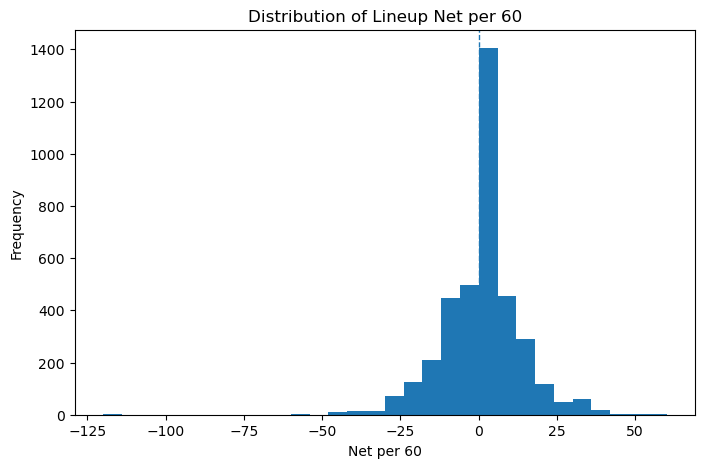

In [42]:
plt.figure(figsize=(8, 5))
plt.hist(lineup_perf["net_per_60"], bins=30)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Net per 60")
plt.ylabel("Frequency")
plt.title("Distribution of Lineup Net per 60")
plt.show()

## Create modeling dataset

We use the reliable lineup dataset as the modeling base to reduce noise from low-sample lineups.

This improves model stability and avoids overfitting to short-duration lineup outcomes.

In [43]:
model_df = reliable_lineups[
    reliable_lineups["total_duration"] >= 25
].copy()

model_df.shapemodel_df = reliable_lineups.copy()

model_df.shape

C:\Users\jmontanez\AppData\Local\Temp\ipykernel_21140\2064942303.py:5: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  model_df.shapemodel_df = reliable_lineups.copy()


(1195, 8)

##  Parse lineup identifiers

Lineup identifiers are loaded from CSV as strings. We parse them back into Python lists so player-level features can be computed.

In [44]:
import ast

def parse_lineup(lineup_str):
    if isinstance(lineup_str, list):
        return lineup_str

    try:
        return list(ast.literal_eval(lineup_str))
    except:
        return []

model_df["home_lineup_parsed"] = model_df["home_lineup_tuple"].apply(parse_lineup)
model_df["away_lineup_parsed"] = model_df["away_lineup_tuple"].apply(parse_lineup)

model_df[["home_lineup_tuple", "home_lineup_parsed"]].head()

,home_lineup_tuple,home_lineup_parsed
0,"('1000', '1005', '1508', '1509', '165')","[1000, 1005, 1508, 1509, 165]"
1,"('1000', '1005', '1508', '1509', '165')","[1000, 1005, 1508, 1509, 165]"
2,"('1000', '1005', '1508', '165', '1749')","[1000, 1005, 1508, 165, 1749]"
4,"('1000', '1005', '1508', '165', '1749')","[1000, 1005, 1508, 165, 1749]"
5,"('1000', '1005', '1508', '165', '1749')","[1000, 1005, 1508, 165, 1749]"


## Build player impact features

We enrich lineup-level data with player-level information.

For each lineup, we compute summary features based on the historical impact of the players in that lineup.

In [45]:
player_impact["player_id"] = player_impact["player_id"].astype(str)

player_impact_lookup = dict(
    zip(player_impact["player_id"], player_impact["impact_per_60_sec"])
)

def lineup_player_features(lineup):
    impacts = [
        player_impact_lookup.get(str(player), 0)
        for player in lineup
    ]

    if len(impacts) == 0:
        return pd.Series({
            "avg_player_impact": 0,
            "max_player_impact": 0,
            "min_player_impact": 0,
            "std_player_impact": 0
        })

    return pd.Series({
        "avg_player_impact": np.mean(impacts),
        "max_player_impact": np.max(impacts),
        "min_player_impact": np.min(impacts),
        "std_player_impact": np.std(impacts)
    })





In [46]:
# Build home lineup player features

home_player_features = model_df["home_lineup_parsed"].apply(
    lineup_player_features
)

home_player_features.head()

,avg_player_impact,max_player_impact,min_player_impact,std_player_impact
0,0.003570,0.015723,-0.011528,0.009232
1,0.003570,0.015723,-0.011528,0.009232
2,0.001117,0.008326,-0.011528,0.007048
4,0.001117,0.008326,-0.011528,0.007048
5,0.001117,0.008326,-0.011528,0.007048


In [47]:
# Build away lineup player features


away_player_features = model_df["away_lineup_parsed"].apply(
    lineup_player_features
)

away_player_features.columns = [
    f"away_{col}" for col in away_player_features.columns
]

away_player_features.head()

,away_avg_player_impact,away_max_player_impact,away_min_player_impact,away_std_player_impact
0,-0.007264,0.002986,-0.033382,0.013492
1,-0.004191,0.018349,-0.033382,0.016816
2,-0.002741,0.008641,-0.009690,0.006442
4,0.010297,0.031065,-0.009174,0.012915
5,0.015429,0.031065,0.009356,0.007993


In [48]:
# Combine lineup feature sets

feature_df = pd.concat(
    [
        home_player_features.reset_index(drop=True),
        away_player_features.reset_index(drop=True)
    ],
    axis=1
)


# Differential features

feature_df["avg_impact_diff"] = (
    feature_df["avg_player_impact"]
    - feature_df["away_avg_player_impact"]
)

feature_df["max_impact_diff"] = (
    feature_df["max_player_impact"]
    - feature_df["away_max_player_impact"]
)

feature_df["min_impact_diff"] = (
    feature_df["min_player_impact"]
    - feature_df["away_min_player_impact"]
)

feature_df["std_impact_diff"] = (
    feature_df["std_player_impact"]
    - feature_df["away_std_player_impact"]
)




In [49]:
# Nonlinear interaction features

feature_df["impact_balance"] = (
    abs(feature_df["avg_impact_diff"])
)

feature_df["star_gap"] = (
    feature_df["max_player_impact"]
    - feature_df["away_max_player_impact"]
)

## Assemble modeling features

The final feature set combines usage-based features with player-impact-based lineup features.

In [50]:
# Add usage-based lineup features


base_features = model_df[
    [
        "total_duration",
        "total_stints"
    ]
].reset_index(drop=True)


# Final modeling dataset

X = pd.concat(
    [
        base_features,
        feature_df.reset_index(drop=True)
    ],
    axis=1
)

y = model_df["net_per_60"].reset_index(drop=True)

In [51]:
# Remove extreme target outliers

q_low = y.quantile(0.02)
q_high = y.quantile(0.98)

valid_mask = (
    (y >= q_low) &
    (y <= q_high)
)

X = X[valid_mask].reset_index(drop=True)
y = y[valid_mask].reset_index(drop=True)

print("Model dataset shape:", X.shape)

X.head()

Model dataset shape: (1147, 16)


,total_duration,total_stints,avg_player_impact,max_player_impact,min_player_impact,std_player_impact,away_avg_player_impact,away_max_player_impact,away_min_player_impact,away_std_player_impact,avg_impact_diff,max_impact_diff,min_impact_diff,std_impact_diff,impact_balance,star_gap
0,55,1,0.003570,0.015723,-0.011528,0.009232,-0.007264,0.002986,-0.033382,0.013492,0.010834,0.012737,0.021854,-0.004260,0.010834,0.012737
1,27,3,0.003570,0.015723,-0.011528,0.009232,-0.004191,0.018349,-0.033382,0.016816,0.007761,-0.002625,0.021854,-0.007584,0.007761,-0.002625
2,70,3,0.001117,0.008326,-0.011528,0.007048,-0.002741,0.008641,-0.009690,0.006442,0.003858,-0.000315,-0.001839,0.000606,0.003858,-0.000315
3,104,2,0.001117,0.008326,-0.011528,0.007048,0.015429,0.031065,0.009356,0.007993,-0.014312,-0.022739,-0.020884,-0.000946,0.014312,-0.022739
4,58,3,0.001117,0.008326,-0.011528,0.007048,-0.023089,-0.017613,-0.041497,0.009228,0.024206,0.025939,0.029968,-0.002180,0.024206,0.025939


##  Train/test split

We split the dataset into training and testing sets to evaluate whether the model can generalize to unseen lineups.

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (860, 16)
Testing shape: (287, 16)


##  Baseline model — Linear Regression

Linear Regression provides a simple and interpretable baseline for lineup performance prediction.

In [53]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_r2 = r2_score(y_test, linear_pred)

linear_rmse, linear_mae, linear_r2

(6.899535698136615, 5.4660267650550765, 0.04236899675225847)

## Regularized model — Ridge Regression

Ridge Regression adds regularization to reduce overfitting, which is useful when working with limited lineup samples.

In [54]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)

ridge_rmse, ridge_mae, ridge_r2

(6.98122568490172, 5.51724894208872, 0.019558193424588644)

## Nonlinear model — Random Forest

Random Forest can capture nonlinear relationships between lineup usage, player impact, and performance.

In [55]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

rf_rmse, rf_mae, rf_r2

(6.949774401350341, 5.475942949236108, 0.028372316993794944)

## Cross-validation evaluation



In [56]:
from sklearn.model_selection import cross_val_score

rf_cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Random Forest CV R² scores:")
print(rf_cv_scores)

print("\nAverage CV R²:")
print(rf_cv_scores.mean())

Random Forest CV R² scores:
[-0.01158251  0.04833933 -0.08623129  0.05141925  0.04392613]

Average CV R²:
0.009174182097544992


##  Model comparison

We compare baseline, regularized, and nonlinear models using RMSE, MAE, and R².

In [57]:
model_results = pd.DataFrame({
    "model": ["Linear Regression", "Ridge Regression", "Random Forest"],
    "rmse": [linear_rmse, ridge_rmse, rf_rmse],
    "mae": [linear_mae, ridge_mae, rf_mae],
    "r2": [linear_r2, ridge_r2, rf_r2]
})

model_results.sort_values("rmse")

,model,rmse,mae,r2
0,Linear Regression,6.899536,5.466027,0.042369
2,Random Forest,6.949774,5.475943,0.028372
1,Ridge Regression,6.981226,5.517249,0.019558


## Modeling result interpretation

The modeling results show that lineup performance contains measurable predictive signal, although the relationship remains highly variable.

Among the evaluated models, the best-performing approach achieved the lowest prediction error while capturing part of the relationship between lineup composition, usage patterns, and historical player impact.

Predictive performance remains moderate, which is expected in basketball lineup modeling due to the influence of opponent matchups, game context, rotation patterns, and short-sample variability.

These results demonstrate that player-impact-derived features and lineup differential features contribute useful information for estimating lineup performance, while also highlighting opportunities for future feature engineering and larger-scale training data.

## Actual vs predicted performance

This plot compares predicted lineup performance against observed lineup performance.

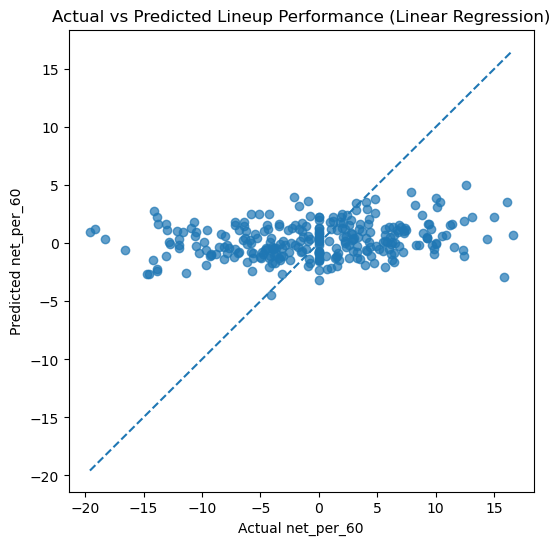

In [58]:
best_model_name = model_results.sort_values("rmse").iloc[0]["model"]

if best_model_name == "Linear Regression":
    best_pred = linear_pred
elif best_model_name == "Ridge Regression":
    best_pred = ridge_pred
else:
    best_pred = rf_pred

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_pred, alpha=0.7)

min_val = min(y_test.min(), best_pred.min())
max_val = max(y_test.max(), best_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual net_per_60")
plt.ylabel("Predicted net_per_60")
plt.title(f"Actual vs Predicted Lineup Performance ({best_model_name})")
plt.show()

## Feature importance

Feature importance helps explain which variables contribute most to the model’s predictions.

In [59]:
if best_model_name == "Random Forest":
    feature_importance = pd.DataFrame({
        "feature": X.columns,
        "importance": rf_model.feature_importances_
    }).sort_values("importance", ascending=False)
else:
    selected_model = linear_model if best_model_name == "Linear Regression" else ridge_model

    feature_importance = pd.DataFrame({
        "feature": X.columns,
        "coefficient": selected_model.coef_
    }).sort_values("coefficient", ascending=False)

feature_importance

,feature,coefficient
9,away_std_player_impact,247.269642
8,away_min_player_impact,71.446813
15,star_gap,61.907981
11,max_impact_diff,61.907981
5,std_player_impact,33.188864
4,min_player_impact,25.191585
3,max_player_impact,11.894474
6,away_avg_player_impact,1.967531
0,total_duration,-0.004150
1,total_stints,-0.008993


## Modeling interpretation

This notebook establishes a baseline framework for predicting lineup performance.

Because the dataset is still limited to a relatively small multi-game sample, predictive accuracy should be interpreted cautiously. The purpose of this notebook is not to claim a final production-grade model, but to demonstrate a scalable modeling workflow.

The model results help identify whether usage features and player-impact-derived features contain useful signal for estimating lineup performance.

As more games are added, this framework can be retrained and evaluated on a larger, more representative dataset.

##  Save modeling outputs

We save the model comparison table and feature importance results for reporting, dashboard integration, and future model iteration.

In [60]:
model_results.to_csv("../data/processed/model_results.csv", index=False)
feature_importance.to_csv("../data/processed/model_feature_importance.csv", index=False)

print("Modeling outputs saved successfully.")

Modeling outputs saved successfully.


## Key findings

This notebook introduces a predictive modeling framework for lineup performance.

Key outcomes:

- A baseline model was trained to predict lineup `net_per_60`
- Player-impact-derived features were added to improve lineup representation
- Linear, regularized, and nonlinear models were compared
- Model performance remains limited by sample size and target variability
- The framework is scalable and can improve as more games are included

## Next step

The next stage is to expand the modeling dataset further and connect the best-performing model outputs to the dashboard.

This will allow the final app to move from descriptive analytics toward predictive decision support.